[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Univariate_Temperature_RNN_pt2.ipynb)

# Univariate Temperature RNN, Part 2: Reload, Explain, Roll Forward
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Part 1 trained an LSTM on ten years of daily minimum temperatures and saved it. This notebook never trains anything. It **downloads that saved model**, rebuilds the test set, proves the reload, and then asks the two questions Part 1 left open:

1. **What is the model looking at?** - occlusion by lag and gradient saliency on a 10-day window
2. **What happens if you feed its own predictions back in?** - the autoregressive roll-forward, scored by horizon against the dumb baselines

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 7-pt2 — Univariate RNN Pt 2b: reload the saved LSTM, explain it, roll it forward
- No training in this notebook - that's the point. Download the .keras file Part 1 saved, rebuild the SAME windows, prove the MAE matches (~1.74). A model is an artifact you can hand to someone.
- Occlusion: blank one lag (replace it with the training mean) and re-score. Yesterday matters most; the effect fades over about a week. Gradient saliency says the same thing with calculus.
- Autoregressive roll-forward: predict tomorrow, append it, slide, predict the day after... The window fills with the model's own guesses. Watch the single-origin plot: the forecast smooths out toward a seasonal level within a few days - the model stops pretending to know the weather.
- Score it by horizon: day 1 1.78 C (= Part 1), then it settles at ~2.25 by day 3 and STAYS there through day 14 - still better than persistence (2.75) and climatology (3.2) because the window carries the season. Recursive doesn't blow up here: no covariates to fake, and a mean-reverting series. Contrast with demand in the energy notebooks, where it does.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from urllib.request import urlretrieve
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix, f1_score
from keras.models import load_model
import keras
keras.utils.set_random_seed(5509)

## Rebuild the data exactly as Part 1 did

Same file, same `split_sequence`, same look-back of 10, same 90/10 chronological split. No scaling - Part 1 didn't scale either.

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/daily-min-temperatures.csv")

def split_sequence(sequence, n_steps):
    X, y = [], []
    for i in range(len(sequence)):
        end_ix = i + n_steps
        if end_ix > len(sequence) - 1: break
        X.append(sequence[i:end_ix]); y.append(sequence[end_ix])
    return np.array(X), np.array(y)

n_steps = 10
X, y = split_sequence(df["Temp"].values, n_steps)
X = X.reshape(X.shape[0], n_steps, 1)
cut = int(0.9 * len(X))
X_train, X_test, y_train, y_test = X[:cut], X[cut:], y[:cut], y[cut:]
print("test windows:", X_test.shape, "| the model never saw these", len(y_test), "days")

test windows: (364, 10, 1) | the model never saw these 364 days


## Download the saved model and prove it's the same one

In [3]:
urlretrieve("https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/models/Univariate_Temperature_RNN.keras", "Univariate_Temperature_RNN.keras")      # the file the previous notebook saved - now a course asset
model = load_model("Univariate_Temperature_RNN.keras")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30)             │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,615 (45.38 KB)

 Trainable params: 3,871 (15.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,744 (30.25 KB)

In [4]:
pred = model.predict(X_test, verbose=0).ravel()
base_mae = mean_absolute_error(y_test, pred)
print(f"reloaded LSTM test MAE: {base_mae:.2f} C   (Part 1 reported ~1.74)")
print(f"persistence (yesterday): {mean_absolute_error(y_test, X_test[:, -1, 0]):.2f} C | climatology (train mean): {mean_absolute_error(y_test, np.full(len(y_test), y_train.mean())):.2f} C")

reloaded LSTM test MAE: 1.76 C   (Part 1 reported ~1.74)
persistence (yesterday): 2.02 C | climatology (train mean): 3.23 C


## 1. Occlusion by lag

Replace one of the ten days in every test window with the training mean and re-score. The rise in MAE says how much the model leaned on that day.

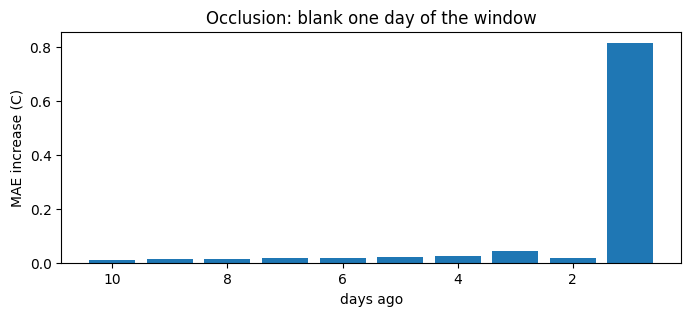

In [5]:
occ = []
for t in range(n_steps):
    Xo = X_test.copy(); Xo[:, t, 0] = y_train.mean()
    occ.append(mean_absolute_error(y_test, model.predict(Xo, verbose=0).ravel()) - base_mae)
days_ago = np.arange(n_steps, 0, -1)
plt.figure(figsize=(8, 3)); plt.bar(days_ago, occ); plt.gca().invert_xaxis()
plt.xlabel("days ago"); plt.ylabel("MAE increase (C)"); plt.title("Occlusion: blank one day of the window"); plt.show()

## 2. Gradient saliency

`d(prediction)/d(input)` for each of the ten days, averaged over the test windows - the training derivative pointed at the inputs.

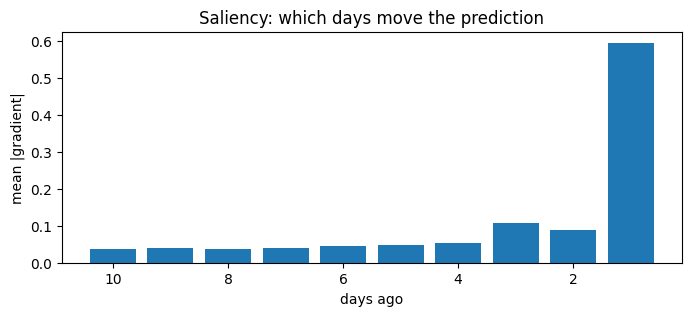

In [6]:
def saliency(model, X):
    x = tf.convert_to_tensor(X, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        out = model(x, training=False)
    return tape.gradient(out, x).numpy()

sal = np.abs(saliency(model, X_test)).mean(axis=0).ravel()
plt.figure(figsize=(8, 3)); plt.bar(days_ago, sal); plt.gca().invert_xaxis()
plt.xlabel("days ago"); plt.ylabel("mean |gradient|"); plt.title("Saliency: which days move the prediction"); plt.show()

## 3. Autoregressive roll-forward

The model predicts *one* day ahead from ten real days. To get a two-week forecast from it you have to **feed the prediction back in** as the newest day and slide the window - and after ten steps the window is entirely the model's own guesses. Roll forward from every test window and score each horizon.

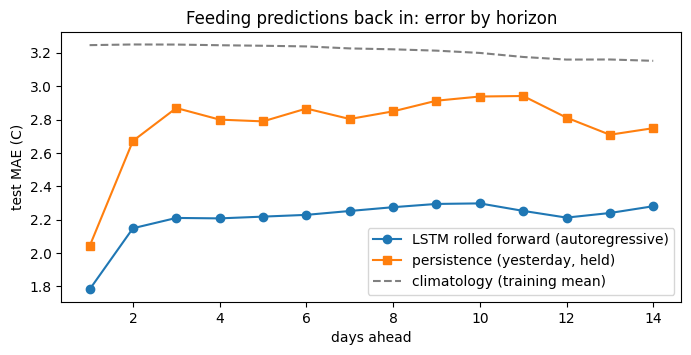

,autoregressive LSTM,persistence,climatology
day +1,1.78,2.04,3.25
day +2,2.15,2.67,3.25
day +3,2.21,2.87,3.25
day +7,2.25,2.80,3.23
day +14,2.28,2.75,3.15


In [7]:
def roll_forward(model, X0, n_out):
    window, preds = X0.copy(), []
    for h in range(n_out):
        p = model.predict(window, verbose=0)                              # (origins, 1)
        preds.append(p.ravel())
        window = np.concatenate([window[:, 1:, :], p[:, None, :]], axis=1)   # slide: drop the oldest day, append OUR prediction
    return np.array(preds).T                                              # (origins, n_out)

n_out = 14
temps = df["Temp"].values
origins = np.arange(cut, len(X) - n_out + 1)                              # every test window that has 14 real days after it
rec = roll_forward(model, X[origins], n_out)
truth = np.stack([temps[o + n_steps : o + n_steps + n_out] for o in origins])
mae_rec = np.abs(rec - truth).mean(axis=0)
mae_persist = np.array([mean_absolute_error(truth[:, h], X[origins][:, -1, 0]) for h in range(n_out)])   # "it stays like yesterday"
mae_clim = np.abs(truth - y_train.mean()).mean(axis=0)

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, n_out+1), mae_rec, marker="o", label="LSTM rolled forward (autoregressive)")
plt.plot(range(1, n_out+1), mae_persist, marker="s", label="persistence (yesterday, held)")
plt.plot(range(1, n_out+1), mae_clim, "--", color="gray", label="climatology (training mean)")
plt.xlabel("days ahead"); plt.ylabel("test MAE (C)"); plt.title("Feeding predictions back in: error by horizon"); plt.legend(); plt.show()
pd.DataFrame({"autoregressive LSTM": mae_rec, "persistence": mae_persist, "climatology": mae_clim}, index=[f"day +{h}" for h in range(1, n_out+1)]).round(2).iloc[[0, 1, 2, 6, 13]]

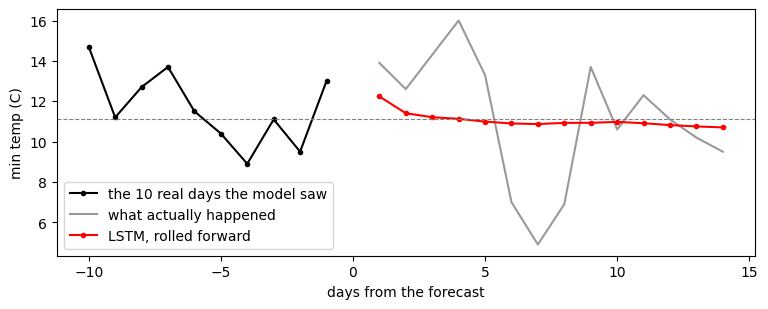

In [8]:
# one origin: watch the forecast decay toward the mean
o = 120
plt.figure(figsize=(9, 3.2))
plt.plot(range(-n_steps, 0), X[origins[o]].ravel(), "k.-", label="the 10 real days the model saw")
plt.plot(range(1, n_out+1), truth[o], "k", alpha=0.4, label="what actually happened")
plt.plot(range(1, n_out+1), rec[o], "r.-", label="LSTM, rolled forward")
plt.axhline(y_train.mean(), color="gray", ls="--", lw=0.8); plt.xlabel("days from the forecast"); plt.ylabel("min temp (C)"); plt.legend(); plt.show()

## What you just saw

- A **saved model is a reusable artifact**: same file, same predictions, on a different day, in a different notebook.
- The model leans on **yesterday** and the effect fades within the window - it learned persistence-plus-a-correction, which is what beat the baselines in Part 1.
- **Rolled forward, it decays toward the mean.** That's not a bug: with no future information the best guess *is* the climatology. Recursive forecasting is fine for a few steps; for a real multi-step forecast see the strategies notebook (direct and multi-output) in the energy section.

## On your own
- Roll forward from a *winter* origin and a *summer* origin. Which decays faster, and why?
- Replace the model with `Univariate_Temperature_Lags.keras` (the window-method dense net from the lags notebook - same 10-day inputs, shape `(samples, 10)`). Does a dense net roll forward any differently?